In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
data = pd.read_csv('data/IBM.csv')
data = pd.DataFrame(data)
data = np.transpose(data)

#rename the columns of the data frame to the first row of the data frame
data.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
data.index.name = 'Date'
data.index = pd.to_datetime(data.index)
data = data.sort_index(ascending=True)
data

,Open,High,Low,Close,Volume
Date,,,,,
2025-06-10 04:00:00,271.90,271.90,271.88,271.88,17.0
2025-06-10 04:01:00,271.73,271.90,271.70,271.90,21.0
2025-06-10 04:02:00,271.78,271.78,271.78,271.78,1.0
2025-06-10 04:03:00,272.00,272.00,272.00,272.00,2.0
2025-06-10 04:04:00,271.78,272.00,271.68,272.00,12.0
...,...,...,...,...,...
2025-07-09 19:34:00,290.20,290.20,290.20,290.20,10.0
2025-07-09 19:38:00,290.00,290.00,290.00,290.00,1.0
2025-07-09 19:39:00,290.20,290.20,290.20,290.20,3.0


In [5]:
# define a object called Strategy
class Strategy:
    def __init__(self):
        self.data = None
        self.position = 0
        self.orders = []
        self.indicators = {}
    def init(self):
        """Initialize strategy (pre-run)"""
        pass
    
    def next(self,i):
        """Main strategy logic"""
        pass
    
    def buy(self):
        self.orders.append(('buy', self.data.Close.iloc[-1]))
        self.position =1
        return self.position
    def sell(self):
        self.orders.append(('sell', self.data.Close.iloc[-1]))
        self.position =-1
        return self.position
    def I(self, func, *args, **kwargs):
        """添加指标计算"""
        indicator_name = f'{func.__name__}_{args}_{kwargs}'
        if indicator_name not in self.indicators:
            self.indicators[indicator_name] = func( *args)
        return self.indicators[indicator_name]

    # 添加技术指标函数
def SMA(series, window):
        return series.rolling(window).mean()
def crossover(a, b):
        """判断两个序列是否发生交叉"""
        return a.iloc[-2] < b.iloc[-2] and a.iloc[-1] > b.iloc[-1]


In [6]:
def backtest(df, strategy, commission=0.002,  initial_cash=100000):
    strategy_instance = strategy()
    strategy_instance.data = df
    strategy_instance.init()
    slippage = 0.0  # 假设的滑点
    cash = initial_cash
    holdings = 0
    equity = [initial_cash]
    positions = []
    trades = []  # 存储每笔交易信息
    current_trade = None  # 当前未平仓的交易
    
    for i in range(len(df)):
        current_date = df.index[i]
        current_price = df.iloc[i]['Close']
        
        # 调用策略获取信号
        signal = strategy_instance.next(i+1)
        
        # 保存当前持仓方向
        current_position = 1 if holdings > 0 else (-1 if holdings < 0 else 0)
        positions.append(current_position)
        
        # 执行交易逻辑
        if signal is not None and signal != current_position:
            # 先平仓
            if holdings > 0 and signal <= 0:  # 平多仓
                close_price = current_price * (1 - slippage)
                cash += holdings * close_price * (1 - commission)
                
                # 记录交易结束
                if current_trade:
                    current_trade['exit_date'] = current_date
                    current_trade['exit_price'] = close_price
                    current_trade['return_pct'] = (close_price / current_trade['entry_price'] - 1) * 100
                    trades.append(current_trade)
                    current_trade = None
                
                holdings = 0
                
            elif holdings < 0 and signal >= 0:  # 平空仓
                close_price = current_price * (1 + slippage)
                cash += holdings * close_price * (1 - commission)
                
                # 记录交易结束
                if current_trade:
                    current_trade['exit_date'] = current_date
                    current_trade['exit_price'] = close_price
                    current_trade['return_pct'] = (current_trade['entry_price'] / close_price - 1) * 100
                    trades.append(current_trade)
                    current_trade = None
                
                holdings = 0
            
            # 再开新仓
            if signal == 1:  # 开多仓
                buy_price = current_price * (1 + slippage)
                cost_per_share = buy_price * (1 + commission)
                shares = cash / cost_per_share
                holdings = shares
                cash = 0
                
                # 记录新交易
                current_trade = {
                    'entry_date': current_date,
                    'entry_price': buy_price,
                    'direction': 1,
                    'size': shares
                }
                
            elif signal == -1:  # 开空仓
                sell_price = current_price * (1 - slippage)
                proceeds_per_share = sell_price * (1 - commission)
                shares = cash / (sell_price * (1 + commission))
                holdings = -shares
                cash += shares * proceeds_per_share
                
                # 记录新交易
                current_trade = {
                    'entry_date': current_date,
                    'entry_price': sell_price,
                    'direction': -1,
                    'size': shares
                }
        
        # 计算当日权益（现金 + 持仓市值）
        position_value = holdings * current_price
        current_equity = cash + position_value
        equity.append(current_equity)
    
    # 处理最后未平仓的交易
    if current_trade:
        current_trade['exit_date'] = df.index[-1]
        current_trade['exit_price'] = df.iloc[-1]['Close']
        if current_trade['direction'] == 1:
            current_trade['return_pct'] = (current_trade['exit_price'] / current_trade['entry_price'] - 1) * 100
        else:
            current_trade['return_pct'] = (current_trade['entry_price'] / current_trade['exit_price'] - 1) * 100
        trades.append(current_trade)
    
    # 准备计算指标的数据
    equity_series = pd.Series(equity[1:], index=df.index)
    returns = equity_series.pct_change().fillna(0)
    n_days = len(df) #交易日总数
    n_years = n_days / 240 #年数
    
    # 计算基准（买入持有）收益率
    bh_returns = df['Close'].pct_change().fillna(0)
    bh_final_return = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
    
    # 计算回撤
    rolling_max = equity_series.expanding(min_periods=1).max()
    drawdown = (equity_series - rolling_max) / rolling_max
    max_drawdown = drawdown.min() * 100
    avg_drawdown = drawdown.mean() * 100
    
    # 计算交易指标
    trades_df = pd.DataFrame(trades)
    n_trades = len(trades_df)
    
    if n_trades > 0:
        win_rate = (trades_df['return_pct'] > 0).mean() * 100
        best_trade = trades_df['return_pct'].max()
        worst_trade = trades_df['return_pct'].min()
        avg_trade = trades_df['return_pct'].mean()
        
        # 计算交易持续时间
        trades_df['duration'] = (trades_df['exit_date'] - trades_df['entry_date']).dt.days
        max_trade_duration = trades_df['duration'].max()
        avg_trade_duration = trades_df['duration'].mean()
        
        # 盈利因子
        winning_trades = trades_df[trades_df['return_pct'] > 0]
        losing_trades = trades_df[trades_df['return_pct'] <= 0]
        profit_factor = abs(winning_trades['return_pct'].sum() / losing_trades['return_pct'].sum()) if len(losing_trades) > 0 else np.inf
        
        # 期望收益
        expectancy = (winning_trades['return_pct'].mean() * (len(winning_trades)/n_trades) + 
                     losing_trades['return_pct'].mean() * (len(losing_trades)/n_trades))
        
        # SQN (System Quality Number)
        avg_profit_per_trade = trades_df['return_pct'].mean()
        std_profit_per_trade = trades_df['return_pct'].std()
        sqn = (avg_profit_per_trade / std_profit_per_trade) * np.sqrt(n_trades) if std_profit_per_trade != 0 else 0
        
        # 凯利准则
        win_prob = len(winning_trades) / n_trades
        win_loss_ratio = abs(winning_trades['return_pct'].mean() / losing_trades['return_pct'].mean()) if len(losing_trades) > 0 else np.inf
        kelly = win_prob - (1 - win_prob) / win_loss_ratio if win_loss_ratio != np.inf else win_prob
    else:
        win_rate = best_trade = worst_trade = avg_trade = 0
        max_trade_duration = avg_trade_duration = 0
        profit_factor = expectancy = sqn = kelly = 0
    
    # 计算风险指标
    # 年化收益率
    ann_return = ((equity_series.iloc[-1] / initial_cash) ** (1/n_years) - 1) if n_years > 0 else 0
    
    # 年化波动率
    ann_volatility = returns.std() * np.sqrt(240) * 100
    
    # CAGR
    cagr = ((equity_series.iloc[-1] / initial_cash) ** (1/n_years) - 1) * 100 if n_years > 0 else 0
    
    # 夏普比率
    sharpe_ratio = (ann_return *100 / ann_volatility) if ann_volatility != 0 else 0
    
    # 索提诺比率
    downside_returns = returns[returns < 0]
    downside_volatility = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 1 else 0
    sortino_ratio = (ann_return / downside_volatility) if downside_volatility != 0 else 0
    
    # 卡玛比率
    calmar_ratio = (ann_return / abs(max_drawdown/100)) if max_drawdown != 0 else 0
    
    # Alpha 和 Beta
    if len(returns) > 1 and len(bh_returns) > 1:
        covariance = np.cov(returns[1:], bh_returns[1:len(returns)])[0, 1]
        variance = np.var(bh_returns[1:len(returns)])
        beta = covariance / variance if variance != 0 else 0
        alpha = (ann_return - 0.02) - beta * (bh_final_return/n_years - 0.02)  # 假设无风险利率为2%
    else:
        alpha = beta = 0
    
    # 计算持仓时间比例
    exposure_time = (pd.Series(positions) != 0).mean() * 100
    
    # 计算总佣金
    total_commission = 0
    for trade in trades:
        entry_commission = trade['entry_price'] * trade['size'] * commission
        exit_commission = trade['exit_price'] * trade['size'] * commission
        total_commission += entry_commission + exit_commission
    
    # 返回所有统计指标
    stats = {
        'Exposure Time [%]': exposure_time,
        'Equity Final [$]': equity_series.iloc[-1],
        'Equity Final [%]': (equity_series.iloc[-1] / initial_cash ) * 100,
        'Equity Peak [$]': equity_series.max(),
        'Commissions [$]': total_commission,
        'Return [%]': (equity_series.iloc[-1] / initial_cash - 1) * 100,
        'Buy & Hold Return [%]': bh_final_return,
        'Return (Ann.) [%]': ann_return * 100,
        'Volatility (Ann.) [%]': ann_volatility,
        'CAGR [%]': cagr,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio,
        'Alpha [%]': alpha * 100,
        'Beta': beta,
        'Max. Drawdown [%]': max_drawdown,
        'Avg. Drawdown [%]': avg_drawdown,
        '# Trades': n_trades,
        'Win Rate [%]': win_rate,
        'Best Trade [%]': best_trade,
        'Worst Trade [%]': worst_trade,
        'Avg. Trade [%]': avg_trade,
        'Max. Trade Duration': f"{int(max_trade_duration)} days" if max_trade_duration > 0 else "0 days",
        'Avg. Trade Duration': f"{int(avg_trade_duration)} days" if avg_trade_duration > 0 else "0 days",
        'Profit Factor': profit_factor,
        'Expectancy [%]': expectancy,
        'SQN': sqn,
        'Kelly Criterion': kelly,
        '_equity_curve': equity_series,
        '_trades': trades_df
    }
    # 绘制策略和资产收益率曲线
    plt.figure(figsize=(12, 6))
    plt.plot(equity_series/initial_cash, label='Strategy Equity')
    plt.plot(df['Close']/df['Close'][0], label='Asset_closeprice')
    plt.legend()
    plt.title('Strategy Equity Curve')
    plt.xlabel('Date')
    
    return stats

In [17]:
# 纯双均值策略（0）
class SmaCross(Strategy):
    def init(self):
        price = self.data.Close
        self.ma1 = self.I(SMA, price, 10)
        self.ma2 = self.I(SMA, price, 20)
        #
    def next(self,i):
        if i < 20:
            return
        if crossover(self.ma1[:i], self.ma2[:i]):
            return -1
        elif crossover(self.ma2[:i], self.ma1[:i]):
            return 1

C:\Users\wr\AppData\Local\Temp\ipykernel_14824\1735319492.py:231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(df['Close']/df['Close'][0], label='Asset_closeprice')


{'Exposure Time [%]': np.float64(99.81031589698695),
 'Equity Final [$]': np.float64(15691.183949706927),
 'Equity Final [%]': np.float64(156.91183949706925),
 'Equity Peak [$]': np.float64(15712.299721213725),
 'Commissions [$]': np.float64(0.0),
 'Return [%]': np.float64(56.91183949706926),
 'Buy & Hold Return [%]': np.float64(6.734588789171703),
 'Return (Ann.) [%]': np.float64(0.7919378061941318),
 'Volatility (Ann.) [%]': np.float64(1.4466824130942098),
 'CAGR [%]': np.float64(0.7919378061941318),
 'Sharpe Ratio': np.float64(0.5474164882535002),
 'Sortino Ratio': np.float64(0.6436102427032621),
 'Calmar Ratio': np.float64(0.20928638774437394),
 'Alpha [%]': np.float64(-1.390965485926711),
 'Beta': np.float64(0.018679240770387646),
 'Max. Drawdown [%]': np.float64(-3.783990993056933),
 'Avg. Drawdown [%]': np.float64(-0.8794186164070519),
 '# Trades': 1008,
 'Win Rate [%]': np.float64(66.66666666666666),
 'Best Trade [%]': np.float64(1.036213696665489),
 'Worst Trade [%]': np.float

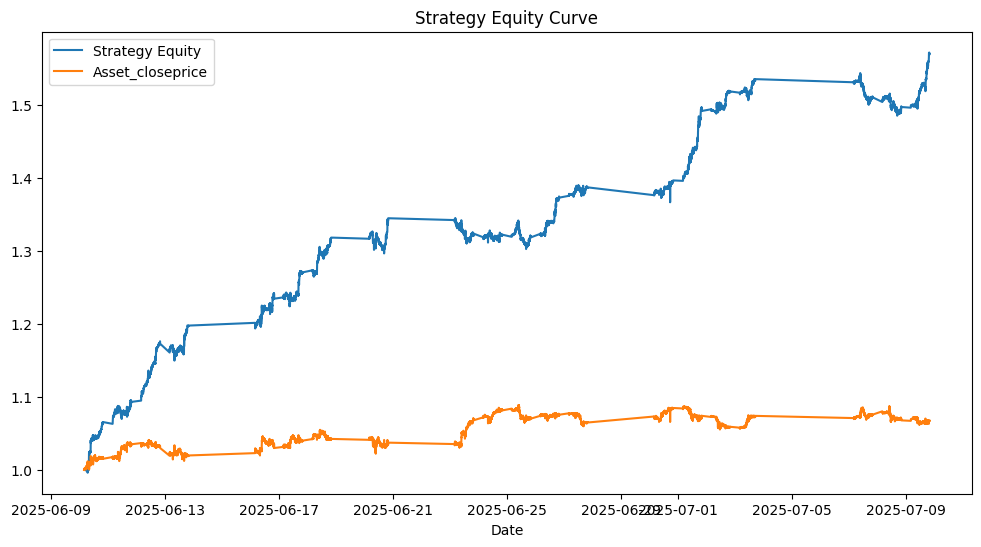

In [18]:
backtest(data,SmaCross,commission=0.0,initial_cash = 10000)